# Extract polygons of Portuguese cities from [CAOP](https://www.dgterritorio.gov.pt/atividades/cartografia/cartografia-tematica/caop)

When extracting the polygons for european cities with >100k citizens from OpenStreetMap (see notebook `check_polygons.ipynb`), some polygons were found to be too big. 

This was the case for 3 Portuguese cities.

Portugal's administrative regions are:
- Distritos
- Municipios (Municipalities)
- Freguesias

## Setup

In [1]:
import requests
from shapely import Polygon, MultiPolygon
from shapely.geometry import shape
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as cx
import textwrap # for long titles
import os
from shapely.ops import unary_union
import pandas as pd
import osmnx as ox

## Import Portuguese geografic regions

Data is downloadable here: [CAOP](https://geo2.dgterritorio.gov.pt/caop/CAOP_Continente_2025-gpkg.zip) (Mainland)

In [2]:
path = "../cities/development/Continente_CAOP2025.gpkg"

In [ ]:
layers = gpd.list_layers("../cities/development/Continente_CAOP2025.gpkg")['name']
layers

0    cont_areas_administrativas
1                cont_distritos
2               cont_freguesias
3               cont_municipios
4                    cont_nuts1
5                    cont_nuts2
6                    cont_nuts3
7                   cont_trocos
8                  layer_styles
9               inf_fonte_troco
Name: name, dtype: str

In [17]:
layers = gpd.list_layers("../cities/development/Continente_CAOP2025.gpkg")['name'].values[:-2]
portugal = {}

for layer in layers:
    
    try:
        
        gdf = gpd.read_file(path, layer=layer)
        display(gdf)

        # Verify it has active geometry before adding
        if gdf.geometry.name in gdf.columns and not gdf.geometry.isna().all():
            portugal[layer] = gdf
    except Exception:
        continue

,id,dtmnfr,freguesia,tipo_area_administrativa,municipio,distrito_ilha,nuts3_cod,nuts3,nuts2,nuts1,area_ha,perimetro_km,geometry
0,1,160938,Vila de Punhe,Área Principal,Viana do Castelo,Viana do Castelo,111,Alto Minho,Norte,Continente,602.67,12,"POLYGON ((-49111.197 218472.077, -49251.865 21..."
1,2,160935,Vila Franca,Área Principal,Viana do Castelo,Viana do Castelo,111,Alto Minho,Norte,Continente,714.60,11,"POLYGON ((-51832.884 223129.561, -51973.664 22..."
2,3,160928,Santa Marta de Portuzelo,Área Principal,Viana do Castelo,Viana do Castelo,111,Alto Minho,Norte,Continente,741.22,16,"POLYGON ((-51260.828 228672.701, -51194.023 22..."
3,4,160926,Perre,Área Principal,Viana do Castelo,Viana do Castelo,111,Alto Minho,Norte,Continente,1308.82,23,"POLYGON ((-56707.879 231359.087, -55327.746 23..."
4,5,160920,Montaria,Área Principal,Viana do Castelo,Viana do Castelo,111,Alto Minho,Norte,Continente,2243.14,21,"POLYGON ((-46142.722 236792.673, -46850.878 23..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3387,3388,141633,União de freguesias da cidade de Santarém,Área Principal,Santarém,Santarém,1D3,Lezíria do Tejo,Oeste e Vale do Tejo,Continente,5551.11,45,"POLYGON ((-49369.419 -54827.206, -49369.179 -5..."
3388,3389,141635,São Vicente do Paul,Área Principal,Santarém,Santarém,1D3,Lezíria do Tejo,Oeste e Vale do Tejo,Continente,4916.03,45,"POLYGON ((-46657.654 -32871.902, -46656.276 -3..."
3389,3390,110302,Aveiras de Baixo,Área Principal,Azambuja,Lisboa,1D3,Lezíria do Tejo,Oeste e Vale do Tejo,Continente,1889.59,23,"POLYGON ((-64710.686 -62067.911, -64703.956 -6..."
3390,3391,110304,Azambuja,Área Principal,Azambuja,Lisboa,1D3,Lezíria do Tejo,Oeste e Vale do Tejo,Continente,8110.97,50,"POLYGON ((-58143.435 -63924.186, -58145.505 -6..."


,dt,distrito,nuts1_cod,nuts1,area_ha,perimetro_km,n_municipios,n_freguesias,geometry
0,01,Aveiro,1,Continente,280094.16,376,19,174.0,"MULTIPOLYGON (((-44918.396 84539.049, -44943.6..."
1,02,Beja,1,Continente,1026332.49,762,14,84.0,"MULTIPOLYGON (((21353.196 -247928.768, 21332.9..."
2,03,Braga,1,Continente,270615.05,351,14,371.0,"MULTIPOLYGON (((-29173.439 189016.541, -29196...."
3,04,Bragança,1,Continente,659853.71,476,12,226.0,"MULTIPOLYGON (((87905.57 162924.965, 87847.549..."
4,05,Castelo Branco,1,Continente,662747.31,569,11,128.0,"MULTIPOLYGON (((36783.65 -3506.686, 36745.61 -..."
5,06,Coimbra,1,Continente,397373.28,527,17,161.0,"MULTIPOLYGON (((-25056.828 37201.851, -24928.7..."
6,07,Évora,1,Continente,739346.41,676,14,75.0,"MULTIPOLYGON (((59094.359 -160014.702, 59000.7..."
7,08,Faro,1,Continente,499679.49,582,16,76.0,"MULTIPOLYGON (((-69669.44 -294268.484, -69670...."
8,09,Guarda,1,Continente,553530.81,516,14,245.0,"MULTIPOLYGON (((35744.382 65384.798, 35708.144..."
9,10,Leiria,1,Continente,350578.68,550,16,116.0,"MULTIPOLYGON (((-85423.362 -45714.016, -85407...."


,dtmnfr,freguesia,municipio,distrito_ilha,nuts3_cod,nuts3,nuts2,nuts1,area_ha,perimetro_km,designacao_simplificada,geometry
0,010103,Aguada de Cima,Águeda,Aveiro,191,Região de Aveiro,Centro,Continente,2839.31,24,Aguada de Cima,"MULTIPOLYGON (((-26330.658 94579.291, -26335.3..."
1,010109,Fermentelos,Águeda,Aveiro,191,Região de Aveiro,Centro,Continente,858.20,13,Fermentelos,"MULTIPOLYGON (((-35996.564 99386.766, -35986.3..."
2,010112,Macinhata do Vouga,Águeda,Aveiro,191,Região de Aveiro,Centro,Continente,3195.44,29,Macinhata do Vouga,"MULTIPOLYGON (((-20410.354 112211.523, -20409...."
3,010119,Valongo do Vouga,Águeda,Aveiro,191,Região de Aveiro,Centro,Continente,4340.48,36,Valongo do Vouga,"MULTIPOLYGON (((-18559.497 108719.411, -18556...."
4,010124,União das freguesias de Recardães e Espinhel,Águeda,Aveiro,191,Região de Aveiro,Centro,Continente,1991.78,22,Recardães e Espinhel,"MULTIPOLYGON (((-27984.277 101887.156, -28032...."
...,...,...,...,...,...,...,...,...,...,...,...,...
3044,182410,São Miguel do Mato,Vouzela,Viseu,194,Viseu Dão Lafões,Centro,Continente,900.29,13,São Miguel do Mato,"MULTIPOLYGON (((7992.567 117241.509, 7993.176 ..."
3045,182411,Ventosa,Vouzela,Viseu,194,Viseu Dão Lafões,Centro,Continente,1833.05,19,Ventosa,"MULTIPOLYGON (((906.69 111902.758, 911.63 1119..."
3046,182413,União das freguesias de Cambra e Carvalhal de ...,Vouzela,Viseu,194,Viseu Dão Lafões,Centro,Continente,3261.21,25,Cambra e Carvalhal de Vermilhas,"MULTIPOLYGON (((724.395 113535.457, 701.348 11..."
3047,182414,União das freguesias de Fataunços e Figueiredo...,Vouzela,Viseu,194,Viseu Dão Lafões,Centro,Continente,1265.97,20,Fataunços e Figueiredo das Donas,"MULTIPOLYGON (((7949.626 119047.829, 7989.946 ..."


,dtmn,municipio,distrito_ilha,nuts3_cod,nuts3,nuts2,nuts1,area_ha,perimetro_km,n_freguesias,geometry
0,0101,Águeda,Aveiro,191,Região de Aveiro,Centro,Continente,33527.44,105,15,"MULTIPOLYGON (((-25647.507 93242.339, -25739.7..."
1,0102,Albergaria-a-Velha,Aveiro,191,Região de Aveiro,Centro,Continente,15882.50,82,6,"MULTIPOLYGON (((-32903.475 104565.493, -32989...."
2,0103,Anadia,Aveiro,191,Região de Aveiro,Centro,Continente,21663.48,75,10,"MULTIPOLYGON (((-18154.369 82414.288, -18150.5..."
3,0104,Arouca,Aveiro,11A,Área Metropolitana do Porto,Norte,Continente,32910.52,118,16,"MULTIPOLYGON (((-14528.269 134014.425, -14662...."
4,0105,Aveiro,Aveiro,191,Região de Aveiro,Centro,Continente,19757.57,77,10,"MULTIPOLYGON (((-32946.27 103875.509, -32915.8..."
...,...,...,...,...,...,...,...,...,...,...,...
273,1820,Tarouca,Viseu,11D,Douro,Norte,Continente,10008.49,73,9,"MULTIPOLYGON (((34415.237 148219.771, 34349.14..."
274,1821,Tondela,Viseu,194,Viseu Dão Lafões,Centro,Continente,37121.73,108,22,"MULTIPOLYGON (((2508.491 88461.83, 2479.582 88..."
275,1822,Vila Nova de Paiva,Viseu,194,Viseu Dão Lafões,Centro,Continente,17553.28,69,5,"MULTIPOLYGON (((34808.673 122308.62, 34811.563..."
276,1823,Viseu,Viseu,194,Viseu Dão Lafões,Centro,Continente,50710.14,123,25,"MULTIPOLYGON (((10754.583 97564.267, 10759.033..."


,codigo,nuts1,area_ha,perimetro_km,n_municipios,n_freguesias,geometry
0,1,Continente,8910214.28,2559,278.0,3049.0,"MULTIPOLYGON (((-92867.587 -139221.614, -92870..."


,codigo,nuts2,nuts1,area_ha,perimetro_km,n_municipios,n_freguesias,geometry
0,11,Norte,Continente,2128586.31,1062,86.0,1504.0,"MULTIPOLYGON (((-40208.653 145186.47, -40208.7..."
1,15,Algarve,Continente,499679.49,582,16.0,76.0,"MULTIPOLYGON (((-69692.591 -294260.664, -69691..."
2,19,Centro,Continente,2327315.89,1130,77.0,844.0,"MULTIPOLYGON (((-66123.253 -20819.137, -66122...."
3,1A,Grande Lisboa,Continente,138998.36,299,9.0,85.0,"MULTIPOLYGON (((-116876.991 -103766.933, -1168..."
4,1B,Península de Setúbal,Continente,162525.50,318,9.0,39.0,"MULTIPOLYGON (((-92871.977 -139220.254, -92872..."
5,1C,Alentejo,Continente,2733003.82,1172,47.0,252.0,"MULTIPOLYGON (((-66387.538 -189635.063, -66386..."
6,1D,Oeste e Vale do Tejo,Continente,920104.91,911,34.0,249.0,"MULTIPOLYGON (((-49605.287 -91992.891, -49641...."


,id,codigo,nuts3,nuts2,nuts1,area_ha,perimetro_km,n_municipios,n_freguesias,geometry
0,1,111,Alto Minho,Norte,Continente,221884.16,266,10,213.0,"MULTIPOLYGON (((-54104.541 216070.182, -54137...."
1,2,112,Cávado,Norte,Continente,124579.07,237,6,179.0,"MULTIPOLYGON (((-43280.299 195100.594, -43272...."
2,3,119,Ave,Norte,Continente,145136.48,323,8,183.0,"MULTIPOLYGON (((-12471.315 186131.057, -12478...."
3,4,11A,Área Metropolitana do Porto,Norte,Continente,204126.92,420,17,208.0,"MULTIPOLYGON (((-40206.652 145273.728, -40206...."
4,5,11B,Alto Tâmega e Barroso,Norte,Continente,292190.84,363,6,118.0,"MULTIPOLYGON (((37942.013 193092.004, 37553.91..."
5,6,11C,Tâmega e Sousa,Norte,Continente,183151.52,297,11,186.0,"MULTIPOLYGON (((-8674.608 148379.85, -8630.727..."
6,7,11D,Douro,Norte,Continente,403157.67,493,19,222.0,"MULTIPOLYGON (((40991.509 133465.324, 40698.07..."
7,8,11E,Terras de Trás-os-Montes,Norte,Continente,554359.66,447,9,195.0,"MULTIPOLYGON (((80188.948 175877.618, 80178.44..."
8,9,150,Algarve,Algarve,Continente,499679.49,582,16,76.0,"MULTIPOLYGON (((-69669.44 -294268.484, -69670...."
9,10,191,Região de Aveiro,Centro,Continente,169285.94,269,11,87.0,"MULTIPOLYGON (((-44894.886 84530.43, -44918.39..."


,identificador,ea_direita,ea_esquerda,paises,estado_limite_admin,significado_linha,nivel_limite_admin,comprimento_km,geometry
0,d9739fbc-a667-11ee-a363-133ab9af3f68,021111,99,Portugal,Definido,Limite e Linha de Costa,3ª Ordem,15.699725,"LINESTRING (-57817.568 -216315.405, -57827.018..."
1,d9492c59-a667-11ee-a363-fbc2f1f39327,090235,98,Portugal#Espanha,Definido,Limite em Terra,1ª Ordem,8.632290,"LINESTRING (110369.327 124649.116, 110369.457 ..."
2,d95df833-a667-11ee-a363-ffcbf5a4be18,031215,131305,Portugal,Não Confirmado,Limite em Terra,3ª Ordem,3.926073,"LINESTRING (-41004.718 190499.692, -41003.309 ..."
3,d97a189c-a667-11ee-a363-a7dee643ac66,031215,131810,Portugal,Não Confirmado,Limite em Terra,3ª Ordem,3.081284,"LINESTRING (-37716.943 186453.915, -37758.543 ..."
4,d97a1ad6-a667-11ee-a363-f79368198777,031215,131631,Portugal,Não Confirmado,Limite em Terra,3ª Ordem,5.011355,"LINESTRING (-39968.052 185870.94, -39995.338 1..."
...,...,...,...,...,...,...,...,...,...
9894,d969890e-a667-11ee-a363-33ba7dfabd84,130147,130136,Portugal,Não Confirmado,Limite em Terra,5ª Ordem,2.403794,"LINESTRING (-6557.827 176946.413, -6361.639 17..."
9895,d96e8be0-a667-11ee-a363-33afa5ecc9b0,020302,150104,Portugal,Definido,Limite em Terra,3ª Ordem,11.641604,"LINESTRING (284.327 -160334.996, 276.64 -16028..."
9896,d697d14c-29c1-11f0-a0b1-b77820fcec29,021125,150914,Portugal,Definido,Limite em Terra,3ª Ordem,1.464400,"LINESTRING (-27029.877 -200613.832, -27024.607..."
9897,d9492c6c-a667-11ee-a363-2bf62254ed89,011702,181007,Portugal,Não Confirmado,Limite em Terra,3ª Ordem,3.151965,"LINESTRING (-13315.772 120270.287, -13344.792 ..."


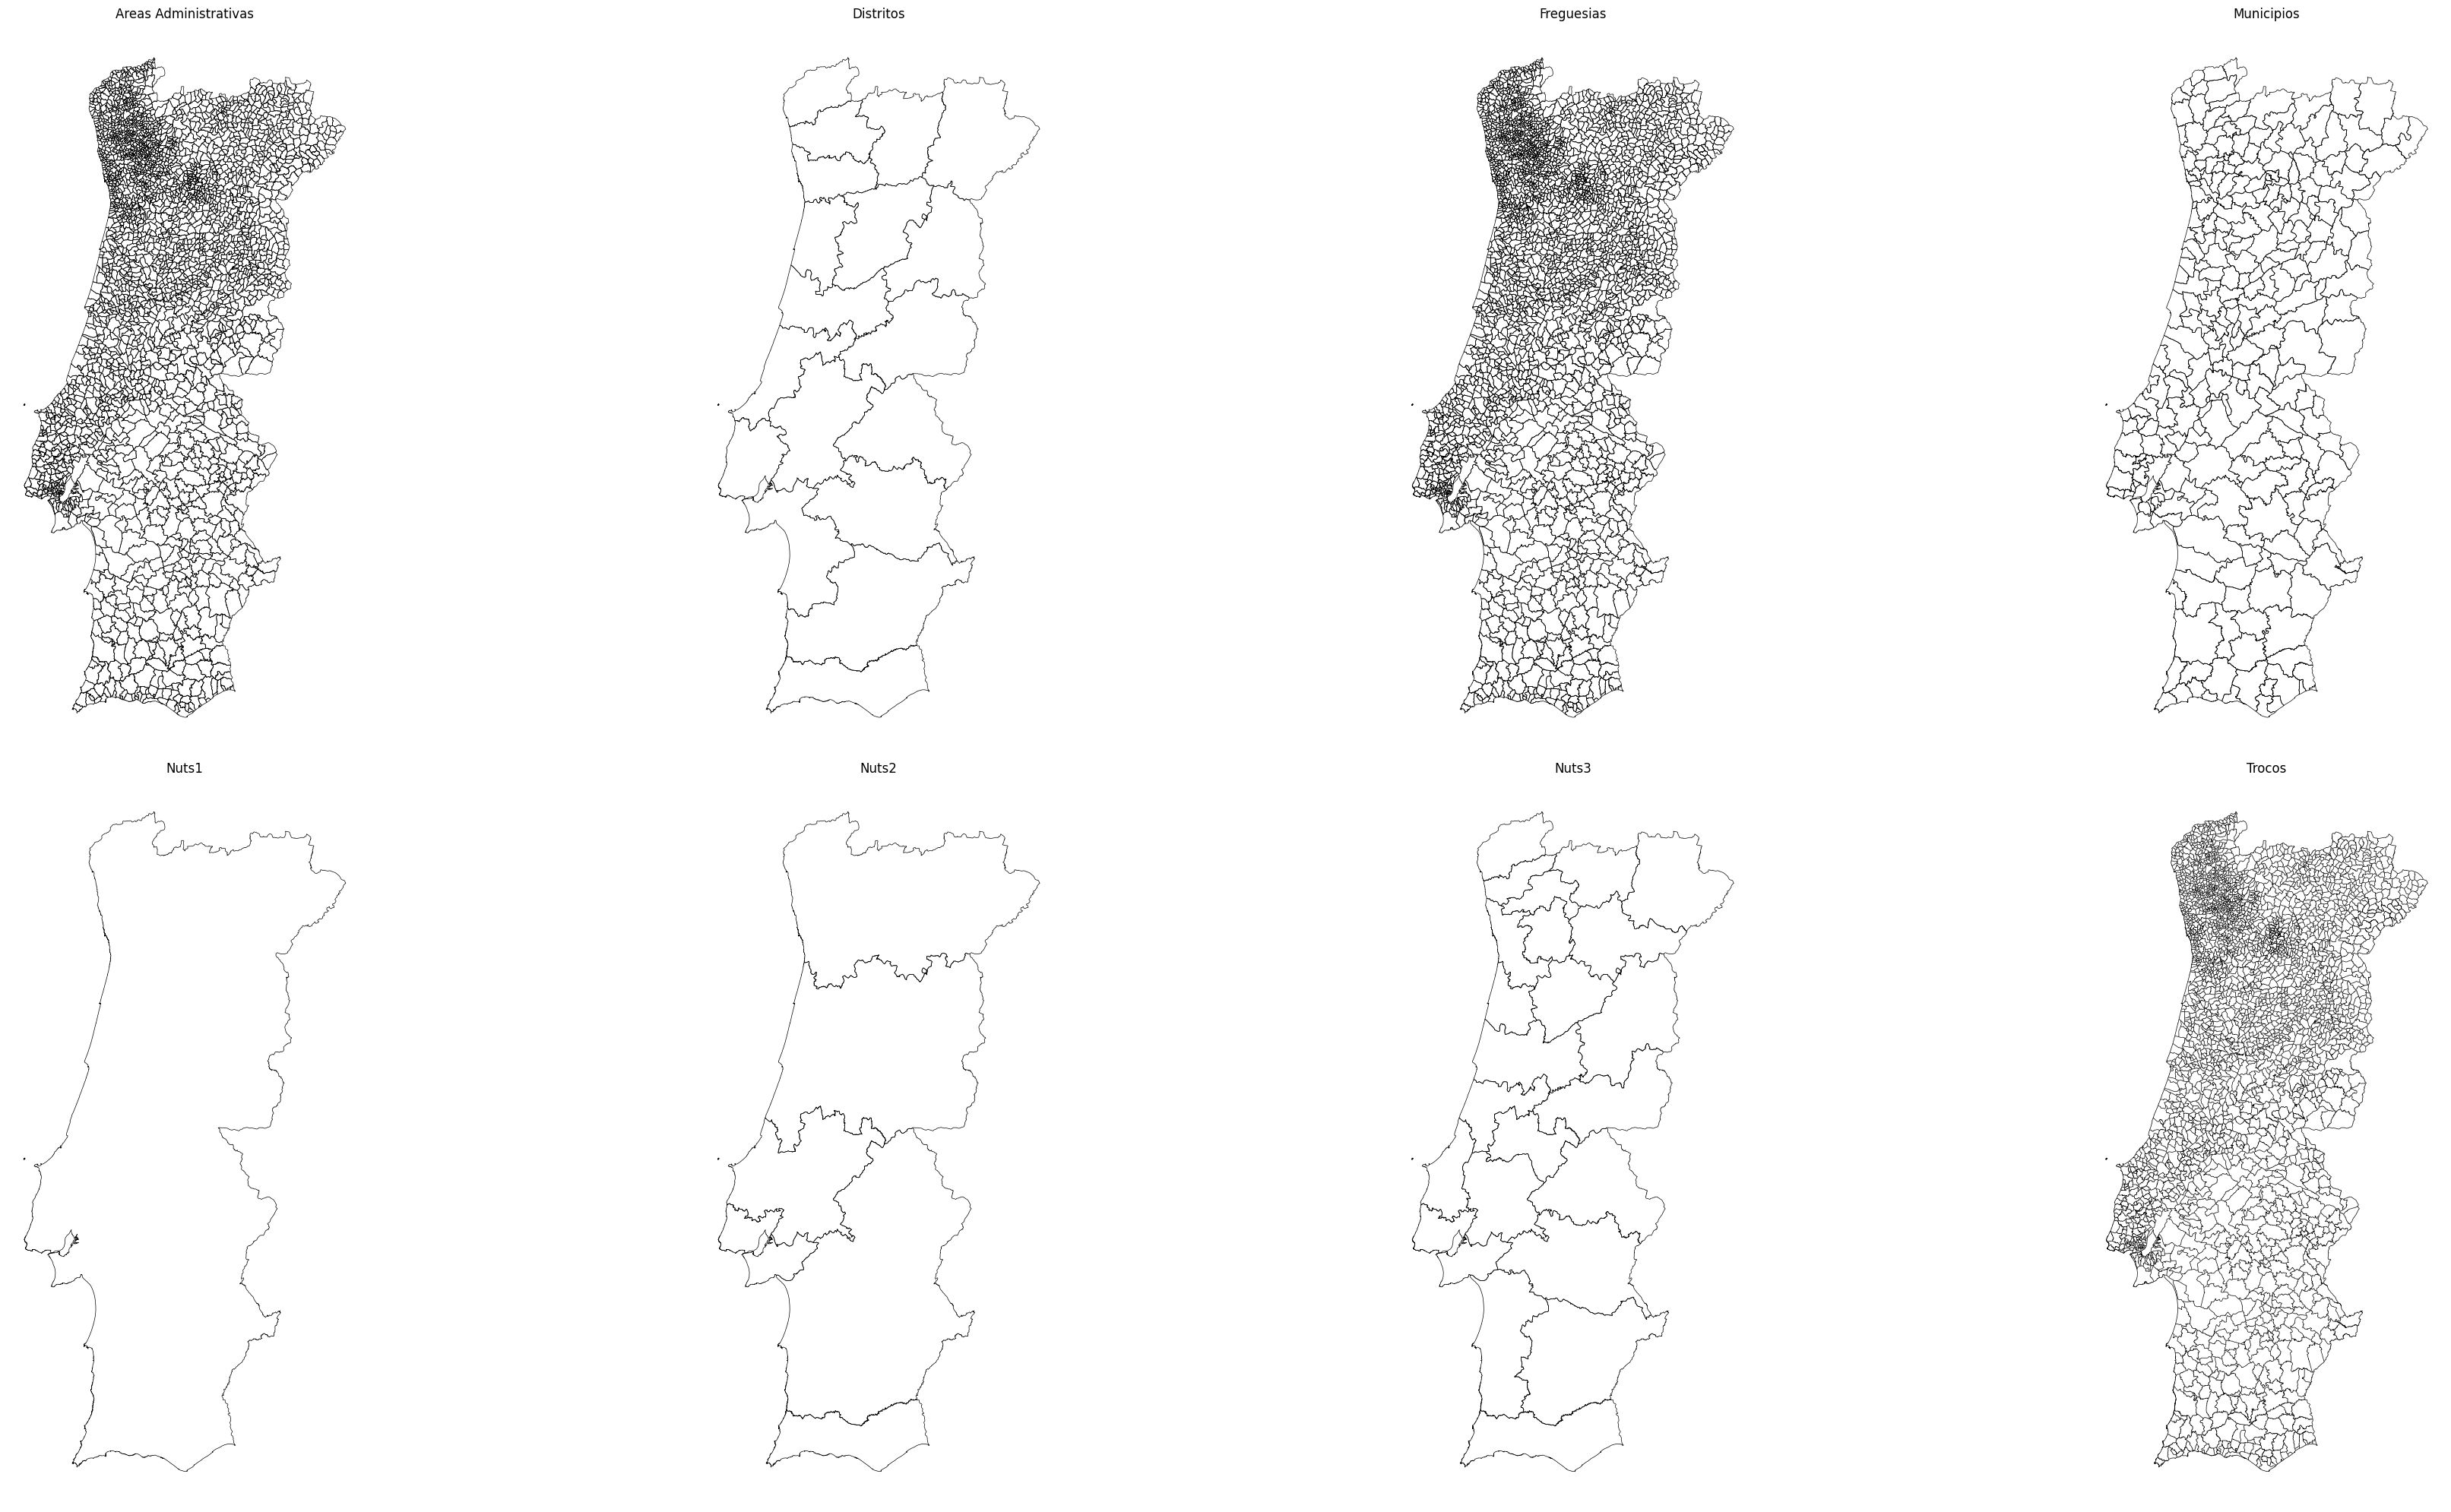

In [22]:
fig, axes = plt.subplots(
    nrows=2, 
    ncols=4, 
    figsize=(40,20)
)

axes = axes.flatten()

# 3. Iterate through and plot each layer
for ax, (layer_name, gdf) in zip(axes, portugal.items()):
    gdf.plot(
        ax=ax,
        facecolor="none",
        edgecolor="black",
        linestyle="-",
        linewidth=0.5
    )
    # Clean formatting for titles
    formatted_title = layer_name.replace("cont_", "").replace("_", " ").title()
    ax.set_title(formatted_title, fontsize=12)
    ax.set_axis_off()  # Removes axis ticks/borders for cleaner spatial output

plt.tight_layout()
plt.show()

In [25]:
freguesias = portugal['cont_freguesias']
freguesias.query("municipio == 'Coimbra'")

,dtmnfr,freguesia,municipio,distrito_ilha,nuts3_cod,nuts3,nuts2,nuts1,area_ha,perimetro_km,designacao_simplificada,geometry
1012,060301,Almalaguês,Coimbra,Coimbra,192,Região de Coimbra,Centro,Continente,2316.39,26,Almalaguês,"MULTIPOLYGON (((-20725.391 54329.725, -20725.5..."
1013,060309,Brasfemes,Coimbra,Coimbra,192,Região de Coimbra,Centro,Continente,917.79,14,Brasfemes,"MULTIPOLYGON (((-20373.719 67919.039, -20371.1..."
1014,060311,Ceira,Coimbra,Coimbra,192,Região de Coimbra,Centro,Continente,1242.49,31,Ceira,"MULTIPOLYGON (((-22465.675 57237.162, -22382.5..."
1015,060312,Cernache,Coimbra,Coimbra,192,Região de Coimbra,Centro,Continente,1916.52,20,Cernache,"MULTIPOLYGON (((-25425.752 50852.985, -25426.3..."
1016,060318,Santo António dos Olivais,Coimbra,Coimbra,192,Região de Coimbra,Centro,Continente,1927.33,23,Santo António dos Olivais,"MULTIPOLYGON (((-21756.876 57982.049, -21902.0..."
1017,060320,São João do Campo,Coimbra,Coimbra,192,Região de Coimbra,Centro,Continente,791.95,14,São João do Campo,"MULTIPOLYGON (((-34722.973 64155.281, -34158.1..."
1018,060324,São Silvestre,Coimbra,Coimbra,192,Região de Coimbra,Centro,Continente,1027.34,16,São Silvestre,"MULTIPOLYGON (((-31810.366 60938.241, -32142.2..."
1019,060329,Torres do Mondego,Coimbra,Coimbra,192,Região de Coimbra,Centro,Continente,1666.29,21,Torres do Mondego,"MULTIPOLYGON (((-17637.484 61128.63, -17604.28..."
1020,060332,União das freguesias de Antuzede e Vil de Matos,Coimbra,Coimbra,192,Região de Coimbra,Centro,Continente,1762.39,22,Antuzede e Vil de Matos,"MULTIPOLYGON (((-28361.465 63839.76, -28349.97..."
1021,060333,União das freguesias de Assafarge e Antanhol,Coimbra,Coimbra,192,Região de Coimbra,Centro,Continente,1951.13,28,Assafarge e Antanhol,"MULTIPOLYGON (((-30011.963 54491.55, -30011.74..."


In [35]:
municipios = portugal['cont_municipios']
municipios.query("municipio == 'Coimbra'")

,dtmn,municipio,distrito_ilha,nuts3_cod,nuts3,nuts2,nuts1,area_ha,perimetro_km,n_freguesias,geometry
72,0603,Coimbra,Coimbra,192,Região de Coimbra,Centro,Continente,31939.94,137,18,"MULTIPOLYGON (((-25473.845 50549.117, -25500.1..."


## Import "unaccepted" Portuguese cities

In [26]:
european_100000pop = pd.read_excel(
    '../cities/development/european_100000pop_comments.xlsx',
    sheet_name = 'Comments',
    usecols = "A:C,E:F,H"
    ).query("accepted == 0 & country_en == 'Portugal'").drop(columns = ['accepted']).sort_values(by=['name_en', 'country_en']).reset_index(drop=True).set_index('name_en')
european_100000pop

,country_en,nominatim_query,country_code,population
name_en,,,,
Braga,Portugal,Braga,PT,148977
Coimbra,Portugal,Coimbra,PT,106768
Vila Nova De Gaia,Portugal,Vila Nova De Gaia,PT,188421


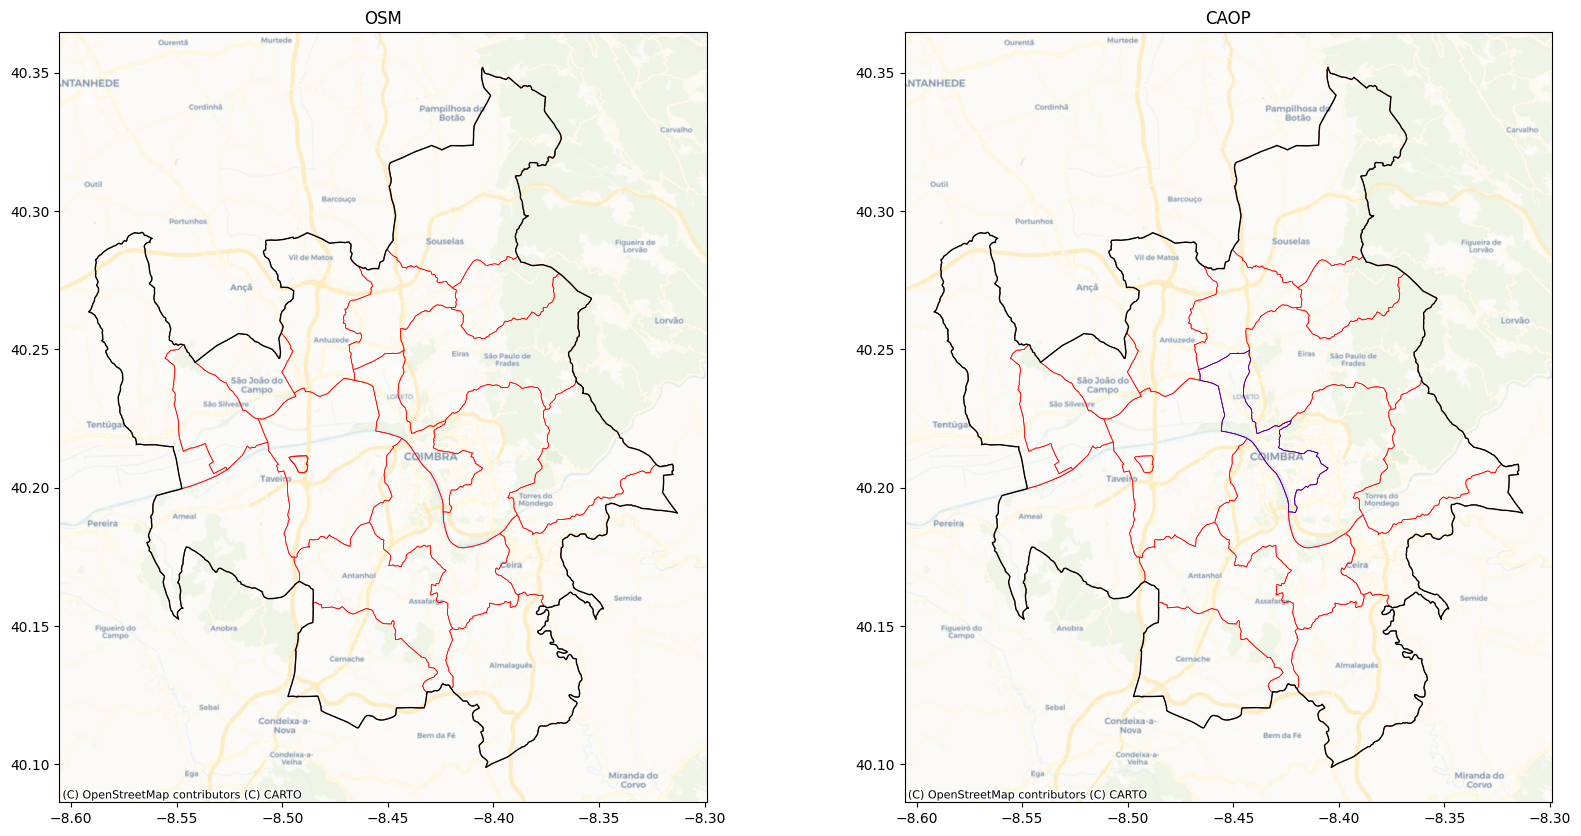

In [48]:
city = "Coimbra"

osm = ox.geocoder.geocode_to_gdf(european_100000pop.loc[city,'nominatim_query'])
osm_poly = osm.geometry.iloc[0]
tags = {
    'boundary': 'administrative',
    'admin_level': '8'  
}
subdivisions = ox.features_from_polygon(osm_poly, tags=tags).query("admin_level == '8'")
clipped_subdivisions = gpd.clip(subdivisions, osm_poly)
clipped_subdivisions = clipped_subdivisions[
    clipped_subdivisions.geometry.type.isin(['Polygon', 'MultiPolygon'])
]



fig, axes = plt.subplots(
    figsize=(20,10),
    ncols = 2,
    nrows = 1
)

ax = axes.flatten()

clipped_subdivisions.plot(
    ax = ax[0],
    facecolor="none",       
    edgecolor="red",        
    linestyle="-",         
    linewidth=0.5
)
osm.plot(
    ax = ax[0],
    facecolor="none",       
    edgecolor="black",        
    linestyle="-",         
    linewidth=1
)
ax[0].set_title("OSM")
cx.add_basemap(ax[0], crs=osm.crs, source=cx.providers.CartoDB.Voyager, alpha = 0.7)


freguesias_from_city = freguesias.query(f"municipio == '{city}'").to_crs(osm.crs)
freguesias_from_city_v2 = freguesias_from_city.query(f"freguesia.str.contains('{city}', case=False, na=False)").to_crs(osm.crs)
municipio = municipios.query(f"municipio == '{city}'").to_crs(osm.crs)

freguesias_from_city.plot(
    ax = ax[1],
    facecolor="none",       
    edgecolor="red",        
    linestyle="-",         
    linewidth=0.5
)
freguesias_from_city_v2.plot(
    ax = ax[1],
    facecolor="none",       
    edgecolor="blue",        
    linestyle="-",         
    linewidth=0.5
)
municipio.plot(
    ax = ax[1],
    facecolor="none",       
    edgecolor="black",        
    linestyle="-",         
    linewidth=1
)
ax[1].set_title("CAOP")

cx.add_basemap(ax[1], crs=freguesias_from_city.crs, source=cx.providers.CartoDB.Voyager, alpha = 0.7)

plt.show()

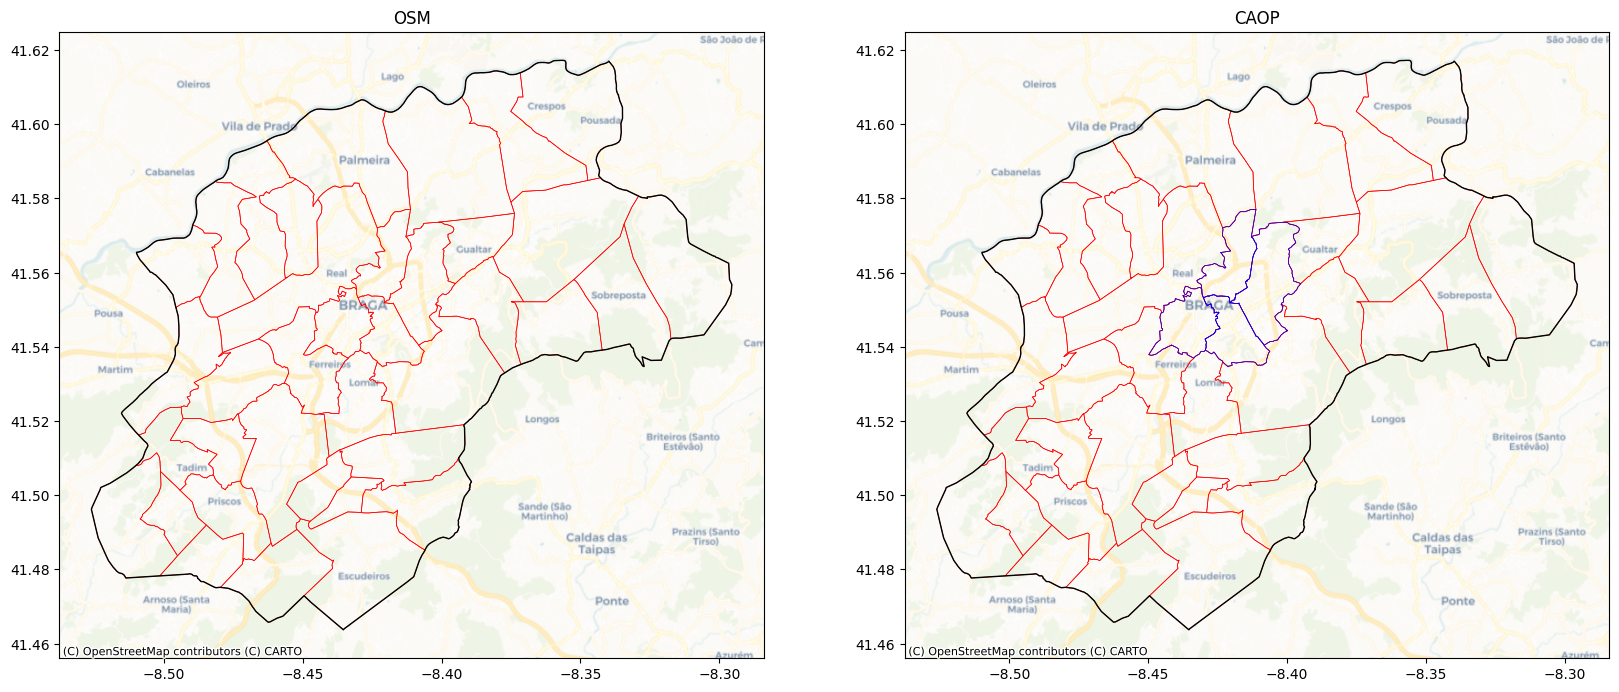

In [47]:
city = "Braga"

osm = ox.geocoder.geocode_to_gdf(european_100000pop.loc[city,'nominatim_query'])
osm_poly = osm.geometry.iloc[0]
tags = {
    'boundary': 'administrative',
    'admin_level': '8'  
}
subdivisions = ox.features_from_polygon(osm_poly, tags=tags).query("admin_level == '8'")
clipped_subdivisions = gpd.clip(subdivisions, osm_poly)
clipped_subdivisions = clipped_subdivisions[
    clipped_subdivisions.geometry.type.isin(['Polygon', 'MultiPolygon'])
]



fig, axes = plt.subplots(
    figsize=(20,10),
    ncols = 2,
    nrows = 1
)

ax = axes.flatten()

clipped_subdivisions.plot(
    ax = ax[0],
    facecolor="none",       
    edgecolor="red",        
    linestyle="-",         
    linewidth=0.5
)
osm.plot(
    ax = ax[0],
    facecolor="none",       
    edgecolor="black",        
    linestyle="-",         
    linewidth=1
)
ax[0].set_title("OSM")
cx.add_basemap(ax[0], crs=osm.crs, source=cx.providers.CartoDB.Voyager, alpha = 0.7)


freguesias_from_city = freguesias.query(f"municipio == '{city}'").to_crs(osm.crs)
freguesias_from_city_v2 = freguesias_from_city.query(f"freguesia.str.contains('{city}', case=False, na=False)").to_crs(osm.crs)
municipio = municipios.query(f"municipio == '{city}'").to_crs(osm.crs)

freguesias_from_city.plot(
    ax = ax[1],
    facecolor="none",       
    edgecolor="red",        
    linestyle="-",         
    linewidth=0.5
)
freguesias_from_city_v2.plot(
    ax = ax[1],
    facecolor="none",       
    edgecolor="blue",        
    linestyle="-",         
    linewidth=0.5
)
municipio.plot(
    ax = ax[1],
    facecolor="none",       
    edgecolor="black",        
    linestyle="-",         
    linewidth=1
)
ax[1].set_title("CAOP")

cx.add_basemap(ax[1], crs=freguesias_from_city.crs, source=cx.providers.CartoDB.Voyager, alpha = 0.7)

plt.show()

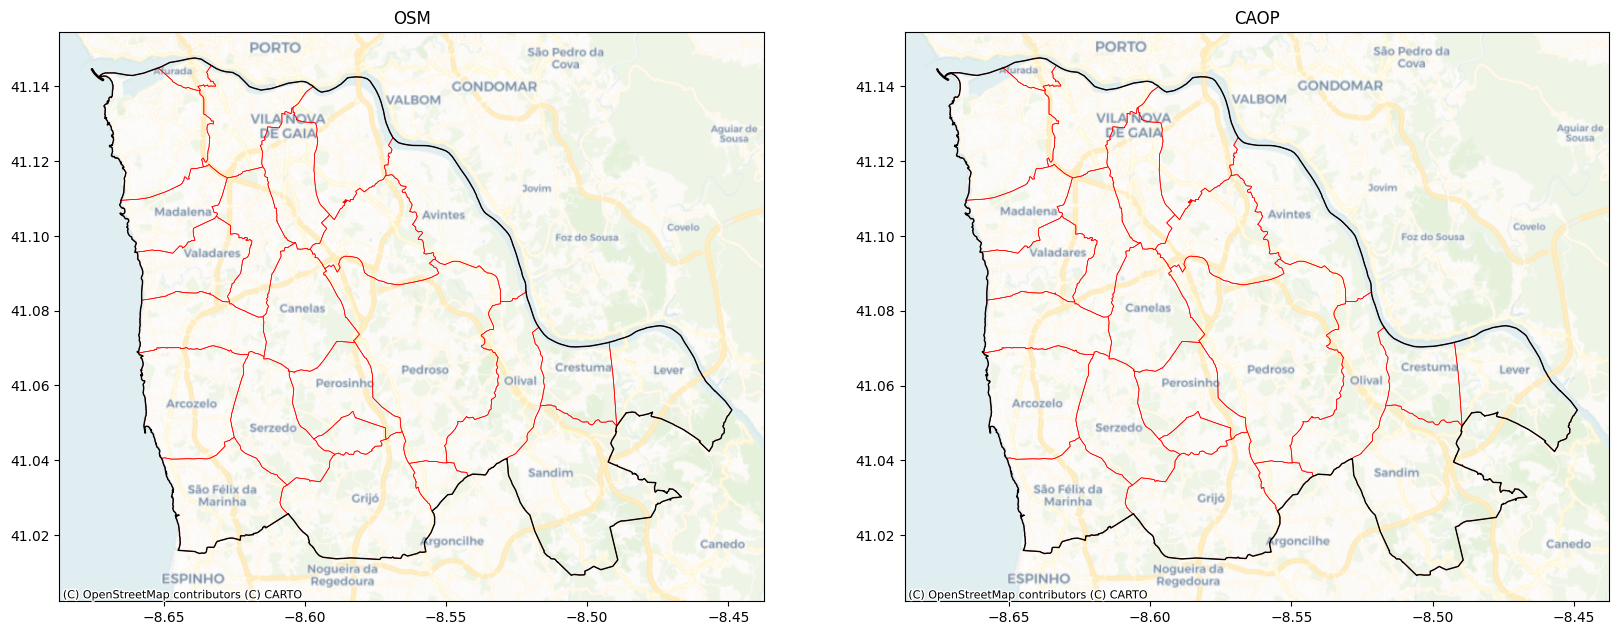

In [54]:
city = "Vila Nova De Gaia"

osm = ox.geocoder.geocode_to_gdf(european_100000pop.loc[city,'nominatim_query'])
osm_poly = osm.geometry.iloc[0]
tags = {
    'boundary': 'administrative',
    'admin_level': '8'  
}
subdivisions = ox.features_from_polygon(osm_poly, tags=tags).query("admin_level == '8'")
clipped_subdivisions = gpd.clip(subdivisions, osm_poly)
clipped_subdivisions = clipped_subdivisions[
    clipped_subdivisions.geometry.type.isin(['Polygon', 'MultiPolygon'])
]



fig, axes = plt.subplots(
    figsize=(20,10),
    ncols = 2,
    nrows = 1
)

ax = axes.flatten()

clipped_subdivisions.plot(
    ax = ax[0],
    facecolor="none",       
    edgecolor="red",        
    linestyle="-",         
    linewidth=0.5
)
osm.plot(
    ax = ax[0],
    facecolor="none",       
    edgecolor="black",        
    linestyle="-",         
    linewidth=1
)
ax[0].set_title("OSM")
cx.add_basemap(ax[0], crs=osm.crs, source=cx.providers.CartoDB.Voyager, alpha = 0.7)

new_city = "Vila Nova de Gaia"

freguesias_from_city = freguesias.query(f"municipio.str.contains('{new_city}', case=False, na=False)").to_crs(osm.crs)
freguesias_from_city_v2 = freguesias_from_city.query(f"freguesia.str.contains('{new_city}', case=False, na=False)").to_crs(osm.crs)
municipio = municipios.query(f"municipio.str.contains('{new_city}', case=False, na=False)").to_crs(osm.crs)

if not freguesias_from_city.empty:
    freguesias_from_city.plot(
        ax=ax[1],
        facecolor="none",       
        edgecolor="red",        
        linestyle="-",         
        linewidth=0.5
    )
if not freguesias_from_city_v2.empty:
    freguesias_from_city_v2.plot(
        ax=ax[1],
        facecolor="none",       
        edgecolor="blue",        
        linestyle="-",         
        linewidth=0.5
    )
if not municipio.empty:
    municipio.plot(
        ax=ax[1],
        facecolor="none",       
        edgecolor="black",        
        linestyle="-",         
        linewidth=1
    )
ax[1].set_title("CAOP")

cx.add_basemap(ax[1], crs=freguesias_from_city.crs, source=cx.providers.CartoDB.Voyager, alpha = 0.7)

plt.show()

# Conclusion

The *Freguesias* don't correspond to the polygons in Google Maps, so they are not considered.